![alt text](download.png)

## PRACTICA OBLIGATORIA: **Arboles de Decisión y Ajuste de Hiperparámetros**

* La práctica obligatoria de esta unidad consiste en encontrar el mejor modelo para resolver un problema de predicción de si los destinatarios de una campaña de marketing adquirirán un producto concreto. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Descripción

En el directorio data encontrarás un dataset que contiene datos relacionados con campañas de marketing directo de una institución bancaria portuguesa (es el dataset "Bank Marketing" de la UCI Machine Learning Repository). Los datos se recopilaron de campañas de marketing telefónico, donde el objetivo principal era predecir si el cliente se suscribiría a un depósito a plazo.

La práctica consiste en completar el proceso de creación de un modelo basado en árboles de decisión que permita predecir si un cliente (dadas unas características similares a las del dataset) "comprará" el depósito a plazo. Sigue los pasos necesarios de un proceso de ML para crear el modelo, optimizar sus hiperparámetros, comparar los resultados de esa optimización con una regresión logística (sin optimizar, con sus hiperparámetros por defecto) y finalmente evaluarlo contra test y hacer una pequeña valoración del resultado obtenido.

Tendrás que hacer la limpieza, split, minieda, selección, tratamiento, primeros entrenamientos, optimización, comparación y evaluación según tu mejor criterio. Eso sí, es obligatorio:
- Identificar el target y analizar su distribución
- Realizar una optimización de hiperparámetros, escogiendo un grid medianemante razonado
- Comparar con el modelo baseline
- Evaluar contra test

AYUDA: La dirección del banco nos proporciona estas notas (en inglés):

 
   **bank client data:**  
   1 - age (numeric)  
   2 - job : type of job (categorical: "admin.","unknown","unemployed","management","housemaid","entrepreneur","student",
                                       "blue-collar","self-employed","retired","technician","services")   
   3 - marital : marital status (categorical: "married","divorced","single"; note: "divorced" means divorced or widowed)  
   4 - education (categorical: "unknown","secondary","primary","tertiary")  
   5 - default: has credit in default? (binary: "yes","no")  
   6 - balance: average yearly balance, in euros (numeric)   
   7 - housing: has housing loan? (binary: "yes","no")  
   8 - loan: has personal loan? (binary: "yes","no")   

   **related with the last contact of the current campaign:**  
   9 - contact: contact communication type (categorical: "unknown","telephone","cellular")   
  10 - day: last contact day of the month (numeric)  
  11 - month: last contact month of year (categorical: "jan", "feb", "mar", ..., "nov", "dec")  
  12 - duration: last contact duration, in seconds (numeric)    

   **other attributes:**  
  13 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)  
  14 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric, -1 means client was not previously contacted)  
  15 - previous: number of contacts performed before this campaign and for this client (numeric)  
  16 - poutcome: outcome of the previous marketing campaign (categorical: "unknown","other","failure","success")

  

**Se priorizará por lo tanto el recall de la clase 1 para así no perder clientes potenciales**

## 1. Imports

In [2]:
import numpy as np
import pandas as pd
pd.options.mode.copy_on_write = True

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
)

## 2. Carga del dataset

In [3]:
data_path = "./data/bank-full.csv"

df = pd.read_csv(data_path, sep=";")
df.shape

(45211, 17)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


## 3. Definición de X e y + EDA mínima

In [5]:
# Comprobación de missing values
df.isna().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [6]:
target_col = "y"

target_dist = df[target_col].value_counts(normalize=True).to_frame("proportion")
target_dist

,proportion
y,
no,0.883015
yes,0.116985


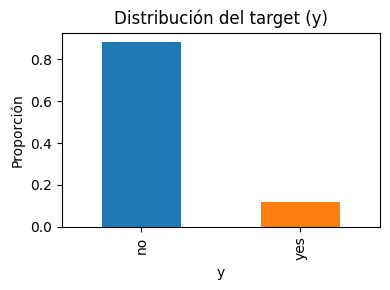

In [7]:
fig, ax = plt.subplots(figsize=(4, 3))
target_dist["proportion"].plot(kind="bar", ax=ax, color=["tab:blue", "tab:orange"])
ax.set_title("Distribución del target (y)")
ax.set_ylabel("Proporción")
plt.tight_layout()
plt.show()

In [8]:
# Definición de X e y
X = df.drop(columns=[target_col])
y = df[target_col].map({"no": 0, "yes": 1})

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = [col for col in X.columns if col not in numeric_features]

numeric_features, categorical_features[:5]

(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'],
 ['job', 'marital', 'education', 'default', 'housing'])

## 4. Train/Test split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42,
)

X_train.shape, X_test.shape

((36168, 16), (9043, 16))

## 5. Modelo base (árbol de decisión)

* Convierto las categóricas
* Defino el Decision Tree
* Hago las predicciones y le pido los parámetros
* Definir el pipe

In [10]:
# Detectar automáticamente columnas categóricas y numéricas
cat_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = X_train.select_dtypes(exclude=["object", "category"]).columns.tolist()

print("Columnas categóricas:", cat_cols)
print("Columnas numéricas:", num_cols)

Columnas categóricas: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
Columnas numéricas: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", "passthrough", num_cols),
    ]
)

pipe = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("clf", DecisionTreeClassifier(random_state=42)),
    ]
)

param_grid = {
    "clf__max_depth": [3, 5, 7, 9, None],
    "clf__min_samples_split": [2, 10, 20],
    "clf__min_samples_leaf": [1, 5, 10],
    "clf__criterion": ["gini", "entropy"],
    "clf__class_weight": [None, "balanced"],
}

grid_search = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

best_params_df = pd.DataFrame([grid_search.best_params_])
best_params_df["best_f1_cv"] = grid_search.best_score_
best_params_df

,clf__class_weight,clf__criterion,clf__max_depth,clf__min_samples_leaf,clf__min_samples_split,best_f1_cv
0,balanced,gini,None,10,2,0.538456


**Se usa GridSearch porque permite seleccionar la mejor combinación de hiperparámetros mediante validación cruzada, mejorando la robustez del modelo**

**Por otro lado, se utiliza F1 como métrica de optimización porque equilibra precisión y recall, evitando modelos que maximicen una métrica a costa de deteriorar la otra.**

## 6. Evaluación con métricas de clasificación

Comparar numéricamente baseline vs árbol optimizado en test (accuracy, F1, ROC-AUC).

Se compara el modelo base con el ajustado para evaluar el impacto real del tuning de hiperparámetros en las métricas clave.

El uso de Pipeline es para garantizar reproducibilidad, evitar data leakage y permite integrar preprocesado y modelo en un único flujo.

In [21]:
def compute_metrics(name, model):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    return {
        "modelo": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba),
    }

pipe.fit(X_train, y_train)

metrics_list = [
    compute_metrics("baseline_tree", pipe),
    compute_metrics("tuned_tree", best_model),
]

metrics_df = pd.DataFrame(metrics_list).set_index("modelo")
metrics_df

,accuracy,f1,roc_auc
modelo,,,
baseline_tree,0.873714,0.465856,0.698906
tuned_tree,0.849939,0.555810,0.866236


In [ ]:
from sklearn.base import clone
from sklearn.metrics import precision_score, recall_score, f1_score, precision_recall_curve

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

model_for_threshold = clone(best_model)
model_for_threshold.fit(X_tr, y_tr)

val_proba = model_for_threshold.predict_proba(X_val)[:, 1]

thresholds = np.linspace(0.2, 0.6, 9)
rows = []
for t in thresholds:
    y_val_pred = (val_proba >= t).astype(int)
    rows.append({
        'threshold': float(t),
        'precision_pos': precision_score(y_val, y_val_pred, zero_division=0),
        'recall_pos': recall_score(y_val, y_val_pred, zero_division=0),
        'f1_pos': f1_score(y_val, y_val_pred, zero_division=0),
    })

thr_df = pd.DataFrame(rows).sort_values('f1_pos', ascending=False)
thr_df

best_threshold = float(thr_df.iloc[0]['threshold'])
best_threshold

0.5

 Vemos ahora si el árbol optimizado está sobreajustando comparando rendimiento en train vs test.

 Se analizan métricas en train y test para verificar la capacidad de generalización y detectar posible sobreajuste.

=== TRAIN ===
              precision    recall  f1-score   support

           0      0.995     0.871     0.929     31937
           1      0.498     0.966     0.657      4231

    accuracy                          0.882     36168
   macro avg      0.746     0.919     0.793     36168
weighted avg      0.937     0.882     0.897     36168



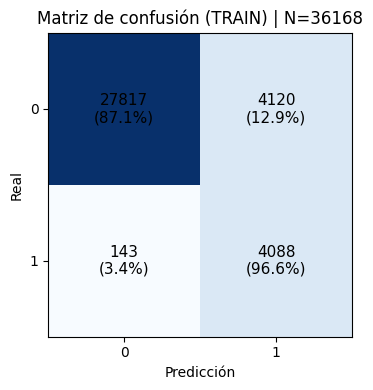


=== TEST ===
              precision    recall  f1-score   support

           0      0.970     0.856     0.910      7985
           1      0.425     0.802     0.556      1058

    accuracy                          0.850      9043
   macro avg      0.698     0.829     0.733      9043
weighted avg      0.907     0.850     0.868      9043



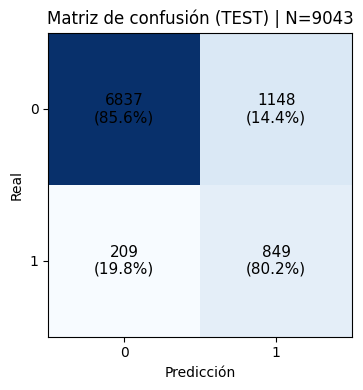

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

def imagen_matriz(y_true, y_pred, title="", labels=None):
    """
    Imagen de matriz de confusión con:
    - Conteos
    - % por fila
    - Total N en el título
    """
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    n = cm.sum()

    # % por fila 
    row_sums = cm.sum(axis=1, keepdims=True)
    row_pct = np.divide(cm, row_sums, out=np.zeros_like(cm, dtype=float), where=row_sums != 0) * 100

    fig, ax = plt.subplots(figsize=(5, 4))

    # desactivar valores automáticos
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=ax, cmap="Blues", colorbar=False, include_values=False)

    # Escribir SOLO nuestros valores personalizados
    for (i, j), val in np.ndenumerate(cm):
        ax.text(j, i, f"{val}\n({row_pct[i, j]:.1f}%)",
                ha="center", va="center", fontsize=11, color="black")

    ax.set_title(f"{title} | N={n}")
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Real")
    plt.tight_layout()
    plt.show()


# Comparación TRAIN vs TEST 
y_pred_train = best_model.predict(X_train)
y_pred_test  = best_model.predict(X_test)

print("=== TRAIN ===")
print(classification_report(y_train, y_pred_train, digits=3))
imagen_matriz(y_train, y_pred_train, title="Matriz de confusión (TRAIN)", labels=[0, 1])

print("\n=== TEST ===")
print(classification_report(y_test, y_pred_test, digits=3))
imagen_matriz(y_test, y_pred_test, title="Matriz de confusión (TEST)", labels=[0, 1])

### 6.1 Curva Precision-Recall y tabla de umbrales

Trazamos la **curva Precision-Recall** sobre el conjunto de test y mostramos una tabla con `precision`, `recall` y `f1` para varios umbrales, de forma que se vea claramente el compromiso entre recuperar más positivos (recall) y aumentar falsos positivos.

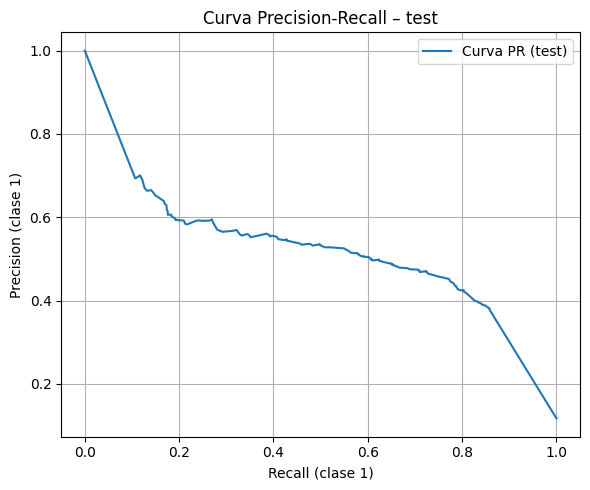

,threshold,precision_pos,recall_pos,f1_pos
0,0.2,0.376086,0.859168,0.523165
1,0.3,0.378018,0.858223,0.524855
2,0.4,0.392416,0.841210,0.535177
3,0.5,0.425138,0.802457,0.555810
4,0.6,0.433403,0.787335,0.559060


In [24]:
# Curva Precision-Recall en TEST y tabla de umbrales

# Probabilidades sobre el test
test_proba = best_model.predict_proba(X_test)[:, 1]

# Curva PR completa
precision, recall, pr_thresholds = precision_recall_curve(y_test, test_proba)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(recall, precision, label="Curva PR (test)")
ax.set_xlabel("Recall (clase 1)")
ax.set_ylabel("Precision (clase 1)")
ax.set_title("Curva Precision-Recall – test")
ax.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Tabla pequeña de métricas para umbrales seleccionados
thr_eval = np.arange(0.2, 0.61, 0.1)
rows_test = []
for t in thr_eval:
    y_pred_t = (test_proba >= t).astype(int)
    rows_test.append({
        "threshold": float(t),
        "precision_pos": precision_score(y_test, y_pred_t, zero_division=0),
        "recall_pos": recall_score(y_test, y_pred_t, zero_division=0),
        "f1_pos": f1_score(y_test, y_pred_t, zero_division=0),
    })

thr_test_df = pd.DataFrame(rows_test)
thr_test_df

**Esta gráfica nos sirve para saber cuánto podemos maximizar el recall sin perder mucha precisión.**

In [25]:
# Umbral por defecto vs umbral ajustado

# Umbral por defecto (0.5)
y_pred_default = (test_proba >= 0.5).astype(int)

# Umbral ajustado (seleccionado en validación)
y_pred_tuned = (test_proba >= best_threshold).astype(int)

print("=== Umbral 0.50 (default) ===")
print(classification_report(y_test, y_pred_default, digits=3))

print("=== Umbral ajustado (best_threshold) ===")
print(f"Umbral elegido: {best_threshold:.2f}\n")
print(classification_report(y_test, y_pred_tuned, digits=3))

=== Umbral 0.50 (default) ===
              precision    recall  f1-score   support

           0      0.970     0.856     0.910      7985
           1      0.425     0.802     0.556      1058

    accuracy                          0.850      9043
   macro avg      0.698     0.829     0.733      9043
weighted avg      0.907     0.850     0.868      9043

=== Umbral ajustado (best_threshold) ===
Umbral elegido: 0.50

              precision    recall  f1-score   support

           0      0.970     0.856     0.910      7985
           1      0.425     0.802     0.556      1058

    accuracy                          0.850      9043
   macro avg      0.698     0.829     0.733      9043
weighted avg      0.907     0.850     0.868      9043



Sale el mismo

### 6.2 Matriz de confusión normalizada y análisis FN vs FP

A partir de aquí mostramos una **matriz de confusión normalizada** (por filas) para el modelo con umbral ajustado, y comentamos el equilibrio entre **falsos negativos (FN)** y **falsos positivos (FP)**, poniendo el foco en que en banca/marketing perder un cliente potencial (FN) suele ser más costoso que contactar de más (FP).

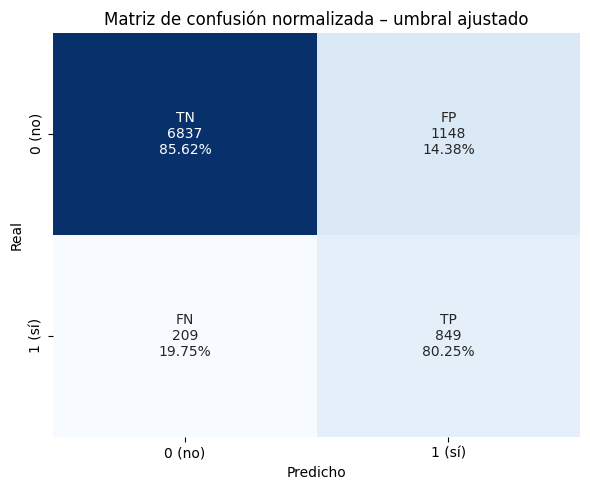

In [26]:
# Matriz de confusión 

cm_tuned = confusion_matrix(y_test, y_pred_tuned)
cm_tuned_norm = cm_tuned.astype(float) / cm_tuned.sum(axis=1, keepdims=True)

labels = np.array([
    [f"TN\n{cm_tuned[0,0]}\n{cm_tuned_norm[0,0]:.2%}", f"FP\n{cm_tuned[0,1]}\n{cm_tuned_norm[0,1]:.2%}"],
    [f"FN\n{cm_tuned[1,0]}\n{cm_tuned_norm[1,0]:.2%}", f"TP\n{cm_tuned[1,1]}\n{cm_tuned_norm[1,1]:.2%}"],
])

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm_tuned,
    annot=labels,
    fmt="",
    cmap="Blues",
    cbar=False,
    ax=ax,
    xticklabels=["0 (no)", "1 (sí)"],
    yticklabels=["0 (no)", "1 (sí)"],
)
ax.set_xlabel("Predicho")
ax.set_ylabel("Real")
ax.set_title("Matriz de confusión normalizada – umbral ajustado")
plt.tight_layout()
plt.show()

En esta matriz normalizada vemos con claridad:
- **FN (casos reales 1 predichos como 0)**: nos interesa que este porcentaje sea lo más bajo posible, porque implica perder clientes que sí habrían contratado el producto.
- **FP (casos reales 0 predichos como 1)**: aumentan con el umbral ajustado, pero es un coste más asumible (contactar de más) comparado con dejar escapar positivos.
- El compromiso elegido prioriza **recall de la clase 1** aun a costa de algo más de FP, alineado con el objetivo del problema.

## 7. Importancia de variables (árbol optimizado)

Analizamos las **importancias de las variables** aprendidas por el árbol de decisión final (`best_model`) y mostramos el **top 10** para interpretar qué factores influyen más en la predicción.

In [27]:
# Importancias de variables

preprocess_step = best_model.named_steps["preprocess"]
ohe = preprocess_step.named_transformers_["cat"]

cat_feature_names = ohe.get_feature_names_out(categorical_features)
num_feature_names = np.array(numeric_features)

feature_names = np.concatenate([cat_feature_names, num_feature_names])

# Importancias del árbol
clf_step = best_model.named_steps["clf"]
importances = clf_step.feature_importances_

feat_imp_df = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .head(10)
)

feat_imp_df.reset_index(drop=True)

,feature,importance
0,duration,0.399338
1,poutcome_success,0.110943
2,contact_unknown,0.076206
3,day,0.070207
4,housing_yes,0.048110
5,balance,0.041871
6,age,0.041566
7,month_jul,0.023729
8,pdays,0.022573
9,month_aug,0.017270


C:\Users\carlo\AppData\Local\Temp\ipykernel_940\2085853442.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


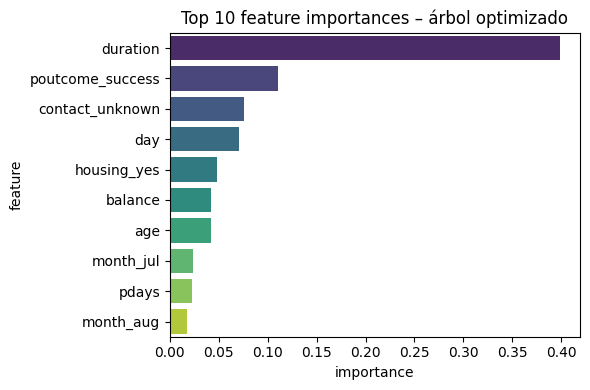

In [ ]:
# Visualización de las 10 más importantes

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(
    data=feat_imp_df,
    x="importance",
    y="feature",
    ax=ax,
    palette="viridis",
)
ax.set_title("Top 10 feature importances – árbol optimizado")
plt.tight_layout()
plt.show()